In [ ]:
# Clear any cached credentials
!rm -rf ~/.config/gh/

# Re-authenticate
from google.colab import auth
auth.authenticate_user()

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
!pip install nbformat --upgrade

import nbformat
from nbformat.v4 import new_notebook
import os

# Assuming drive_folder is defined and mounted in a previous cell
drive_folder = "/content/drive/MyDrive/Group Assignment Group6"
notebook_path = os.path.join(drive_folder, 'DecisionTreeModel_eda_feature_engineering.ipynb')

# Read the notebook
with open(notebook_path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Remove widgets metadata
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

# Define the output path for the cleaned notebook
cleaned_notebook_filename = 'eda_feature_engineering_clean.ipynb'
cleaned_notebook_path = os.path.join(drive_folder, cleaned_notebook_filename)

# Save cleaned notebook to Google Drive
with open(cleaned_notebook_path, 'w') as f:
    nbformat.write(nb, f)

print(f"✅ Cleaned notebook saved to Google Drive at: {cleaned_notebook_path}")

# Download it
from google.colab import files
files.download(cleaned_notebook_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Group Assignment Group6/DecisionTreeModel_eda_feature_engineering.ipynb'

In [ ]:
!pip install torch torchvision torchaudio transformers accelerate bitsandbytes --quiet
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.0 MB/s eta 0:00:00


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os
import random
from datetime import datetime, timedelta

from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

In [ ]:
drive.mount('/content/drive')

drive_folder = "/content/drive/MyDrive/Group Assignment Group6"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Setup Hugging Face Token
import os

# Replace "your_token_here" with your Hugging Face access token
os.environ["HUGGINGFACE_TOKEN"] = userdata.get('HUGGINGFACE_TOKEN')
from huggingface_hub import login
login(token=os.environ["HUGGINGFACE_TOKEN"])

# Load Mistral 7B with 4-bit quantization
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline # Import pipeline here

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

quant_config = BitsAndBytesConfig(load_in_4bit=True)
tokenizer = AutoTokenizer.from_pretrained(model_name, token=os.environ["HUGGINGFACE_TOKEN"])
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=quant_config, token=os.environ["HUGGINGFACE_TOKEN"])


tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

# Exploratory Data Analysis (EDA) with LLM Insights

## Summary Statistics

In [ ]:
df = pd.read_csv(os.path.join(drive_folder, "synthetic_financial_data.csv"))
df.sample(10)

,CustomerID,Age,Education,EmploymentType,EmploymentSector,EmploymentLengthYears,MonthlyIncome,MaritalStatus,Dependents,PropertyOwnership,...,MonthlyDebt,YearsWithBank,HasSavingsAccount,HasCheckingAccount,LoanPurpose,LoanAmount,LoanTermMonths,InterestRate,LoanDefault,LoanPurposeDescription
408,409,25,Associate,Full-Time,Finance,1,8155.693130,Married,0,Own Outright,...,2248.192441,4,1,0,Medical,19422.597116,24,8.183350,0,Applying for financing to cover expenses and e...
352,353,20,High School,Full-Time,Technology,0,3377.605524,Single,0,Own Outright,...,1815.836945,0,1,1,Debt Consolidation,7603.875399,48,13.747292,0,I want to consolidate my debts to the highest ...
62,63,37,Associate,Full-Time,Services,1,5828.857279,Married,0,Own Outright,...,1039.439028,8,1,1,Education,73341.307989,60,4.909150,1,Need funding for my education in the first place.
899,900,20,Associate,Part-Time,Technology,1,1072.838732,Single,0,Living with Parents,...,395.200984,1,1,1,Vacation,13028.472924,48,15.437578,1,Need funds for this project.
344,345,20,Bachelor,Part-Time,Services,0,1224.474819,Single,0,Rent,...,485.348435,2,0,1,Medical,18328.036987,12,13.404454,1,I need a personal loan for a few months.
665,666,24,Associate,Full-Time,Technology,4,2339.540912,Single,1,Rent,...,1235.446677,5,1,0,Debt Consolidation,48292.632452,12,11.811299,1,Need to refinance existing loans because it's ...
55,56,25,Bachelor,Full-Time,Healthcare,1,8052.568293,Single,0,Rent,...,2160.043760,3,1,1,Wedding,20562.992393,48,6.842404,0,Need funds for the project.
452,453,20,Bachelor,Full-Time,Services,1,4176.396821,Single,0,Rent,...,1230.837028,1,1,0,Wedding,13653.213502,36,12.877908,1,Need funds for a few weeks.
244,245,30,Master,Full-Time,Finance,5,14979.904587,Single,0,Own with Mortgage,...,2099.337713,3,1,1,Medical,19095.437014,24,5.640374,1,Applying for financing to cover the cost of a ...
648,649,37,High School,Full-Time,Finance,11,11343.609549,Married,0,Rent,...,3614.726064,0,1,0,Debt Consolidation,13593.600399,24,12.690045,1,Applying for debt consolidation to reduce the ...


In [ ]:
df.head()

,CustomerID,Age,Education,EmploymentType,EmploymentSector,EmploymentLengthYears,MonthlyIncome,MaritalStatus,Dependents,PropertyOwnership,...,MonthlyDebt,YearsWithBank,HasSavingsAccount,HasCheckingAccount,LoanPurpose,LoanAmount,LoanTermMonths,InterestRate,LoanDefault,LoanPurposeDescription
0,1,59,High School,Self-Employed,Technology,11,9067.159786,Single,2,Own with Mortgage,...,1583.065500,7,1,0,Personal,20789.005502,36,3.828919,0,Need funds for the next three years.
1,2,51,Below High School,Full-Time,Government,24,5068.058742,Married,1,Own with Mortgage,...,1332.052087,7,1,1,Personal,27461.583712,48,8.855769,1,I need a personal loan for this to be done.
2,3,24,Bachelor,Unemployed,Manufacturing,0,2557.541824,Single,0,Living with Parents,...,911.536097,2,1,1,Business,68862.744645,240,14.748993,1,Seeking financing to start my own company.
3,4,25,Bachelor,Full-Time,Finance,0,7535.097299,Single,0,Living with Parents,...,514.141526,6,1,0,Wedding,8841.450954,48,4.825886,0,I need a personal loan for me.
4,5,25,Master,Part-Time,Government,5,4798.465251,Married,2,Rent,...,2386.488285,3,0,1,Education,17787.927594,120,18.384157,1,"Applying for student financing for tuition, fe..."


In [ ]:
df.tail()

,CustomerID,Age,Education,EmploymentType,EmploymentSector,EmploymentLengthYears,MonthlyIncome,MaritalStatus,Dependents,PropertyOwnership,...,MonthlyDebt,YearsWithBank,HasSavingsAccount,HasCheckingAccount,LoanPurpose,LoanAmount,LoanTermMonths,InterestRate,LoanDefault,LoanPurposeDescription
995,996,50,Bachelor,Unemployed,Education,0,2290.344312,Single,0,Own with Mortgage,...,1232.671672,17,1,1,Personal,25720.360468,24,15.710300,1,Applying for financing to cover the cost of th...
996,997,19,High School,Self-Employed,Technology,0,3503.489889,Single,0,Own with Mortgage,...,907.252278,1,1,1,Home Purchase,149526.246188,120,9.299824,1,I am applying for a home loan to purchase a ho...
997,998,59,High School,Unemployed,Other,0,3494.953690,Single,2,Own with Mortgage,...,2301.682124,9,0,0,Home Improvement,29032.882205,60,19.153500,1,Need funds for the purchase of the game.
998,999,31,Bachelor,Full-Time,Healthcare,10,12564.097436,Married,3,Own with Mortgage,...,1143.337415,11,0,1,Vacation,14480.714624,24,5.303991,0,Applying for financing to cover the costs of t...
999,1000,55,Bachelor,Self-Employed,Healthcare,13,7870.354103,Married,2,Own Outright,...,2674.630302,1,1,0,Vacation,17511.132728,36,8.354436,0,Applying for financing to cover costs of the p...


In [ ]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Age                     1000 non-null   int64  
 2   Education               1000 non-null   object 
 3   EmploymentType          1000 non-null   object 
 4   EmploymentSector        1000 non-null   object 
 5   EmploymentLengthYears   1000 non-null   int64  
 6   MonthlyIncome           1000 non-null   float64
 7   MaritalStatus           1000 non-null   object 
 8   Dependents              1000 non-null   int64  
 9   PropertyOwnership       1000 non-null   object 
 10  CreditScore             1000 non-null   int64  
 11  ExistingLoans           1000 non-null   int64  
 12  MonthlyDebt             1000 non-null   float64
 13  YearsWithBank           1000 non-null   int64  
 14  HasSavingsAccount       1000 non-null   i

- The dataset has a total of 1,000 rows and 22 columns
- Data Types:
  - CustomerID is represented as an integer (unique identifier for each customer).
  - Age, EmploymentLengthYears, MonthlyIncome, Dependents, CreditScore, ExistingLoans, MonthlyDebt, YearsWithBank, LoanAmount, LoanTermMonths, InterestRate, LoanDefault, HasSavingsAccount, HasCheckingAccount are represented as numeric (integer or float) since they contain measurable or binary 0/1 data.
  - Education, EmploymentType, EmploymentSector, MaritalStatus, PropertyOwnership, LoanPurpose are represented as categorical (category type) because they describe groups or labels rather than numbers.
  - LoanPurposeDescription is represented as an object/string because it contains text descriptions.

In [ ]:
# Summary statistics
df.describe()

,CustomerID,Age,EmploymentLengthYears,MonthlyIncome,Dependents,CreditScore,ExistingLoans,MonthlyDebt,YearsWithBank,HasSavingsAccount,HasCheckingAccount,LoanAmount,LoanTermMonths,InterestRate,LoanDefault
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,500.500000,39.062000,9.050000,6781.692205,0.898000,663.38300,1.473000,1875.015193,8.276000,0.699000,0.704000,57223.258328,81.44400,10.284943,0.50000
std,288.819436,15.669067,10.015778,4335.542986,1.097634,88.15535,1.080944,1212.402229,7.981198,0.458922,0.456719,81621.233508,85.20511,4.367800,0.50025
min,1.000000,18.000000,0.000000,5.643113,0.000000,419.00000,0.000000,3.526190,0.000000,0.000000,0.000000,5027.802355,12.00000,3.505434,0.00000
25%,250.750000,24.000000,1.000000,3147.365989,0.000000,601.75000,1.000000,1002.107622,1.000000,0.000000,0.000000,16611.952487,36.00000,6.780318,0.00000
50%,500.500000,37.000000,5.000000,6231.905681,0.000000,671.00000,1.000000,1580.146038,5.000000,1.000000,1.000000,25864.068035,48.00000,9.615772,0.50000
75%,750.250000,52.000000,14.000000,9699.188285,2.000000,731.00000,2.000000,2477.893103,14.000000,1.000000,1.000000,48879.879610,84.00000,13.411540,1.00000
max,1000.000000,69.000000,39.000000,28457.177055,4.000000,850.00000,4.000000,7559.459832,29.000000,1.000000,1.000000,491389.467162,360.00000,19.998189,1.00000


- CustomerID ranges from 1–1000 (unique identifier).
- Age has an average of ~39 years (min 18, max 69), showing a mix of young to mid-age adults.
- EmploymentLengthYears averages ~9 years, ranging from 0–39, indicating varied work experience levels.
- MonthlyIncome has a wide range (≈ RM5 to RM28,457), with a mean of ~RM6,781; suggests mixed income groups.
- Dependents is mostly 0–2 dependents (median = 0), max is 4.
- CreditScore centers around 663 (min 419, max 850), representing mostly “fair to good” credit profiles.
- ExistingLoans averages 1–2 loans (max 4), meaning most customers already have some credit commitments.
- MonthlyDebt varies significantly (≈ RM3 to RM7,559), average ~RM2,023; debt burdens differ widely.
- YearsWithBank shows a median of 5 years, max 29, indicating generally long-term customer relationships.
- HasSavingsAccount is binary; ~69% have savings (1) and ~31% do not (0).
- HasCheckingAccount is binary; ~70% have checking accounts (1) and ~30% do not (0).
- LoanAmount ranges from ~RM5,027 to RM491,000; mean ~RM57,223, showing large variance in loan size.
- LoanTermMonths typically ranges 12–84 months (max 360), median is 48 months (~4 years loan term).
- InterestRate averages ~10.2% (min 3.5%, max 19.9%), indicating different risk-based pricing.
- LoanDefault is binary; ~50% of customers have defaulted and ~50% non-default.

In [ ]:
clean_df = df.copy()

# Change object to category
clean_df["Education"] = clean_df["Education"].astype("category")
clean_df["EmploymentType"] = clean_df["EmploymentType"].astype("category")
clean_df["EmploymentSector"] = clean_df["EmploymentSector"].astype("category")
clean_df["MaritalStatus"] = clean_df["MaritalStatus"].astype("category")
clean_df["PropertyOwnership"] = clean_df["PropertyOwnership"].astype("category")
clean_df["LoanPurpose"] = clean_df["LoanPurpose"].astype("category")

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   CustomerID              1000 non-null   int64   
 1   Age                     1000 non-null   int64   
 2   Education               1000 non-null   category
 3   EmploymentType          1000 non-null   category
 4   EmploymentSector        1000 non-null   category
 5   EmploymentLengthYears   1000 non-null   int64   
 6   MonthlyIncome           1000 non-null   float64 
 7   MaritalStatus           1000 non-null   category
 8   Dependents              1000 non-null   int64   
 9   PropertyOwnership       1000 non-null   category
 10  CreditScore             1000 non-null   int64   
 11  ExistingLoans           1000 non-null   int64   
 12  MonthlyDebt             1000 non-null   float64 
 13  YearsWithBank           1000 non-null   int64   
 14  HasSavingsAccount       1

In [ ]:
numeric_features = ["Age", "EmploymentLengthYears", "MonthlyIncome", "Dependents", "CreditScore", "ExistingLoans", "MonthlyDebt", "YearsWithBank", "HasSavingsAccount","HasCheckingAccount","LoanAmount", "LoanTermMonths", "InterestRate", "LoanDefault"]
categorical_features = ["Education", "EmploymentType", "EmploymentSector", "MaritalStatus", "PropertyOwnership", "LoanPurpose"]

## Distributions

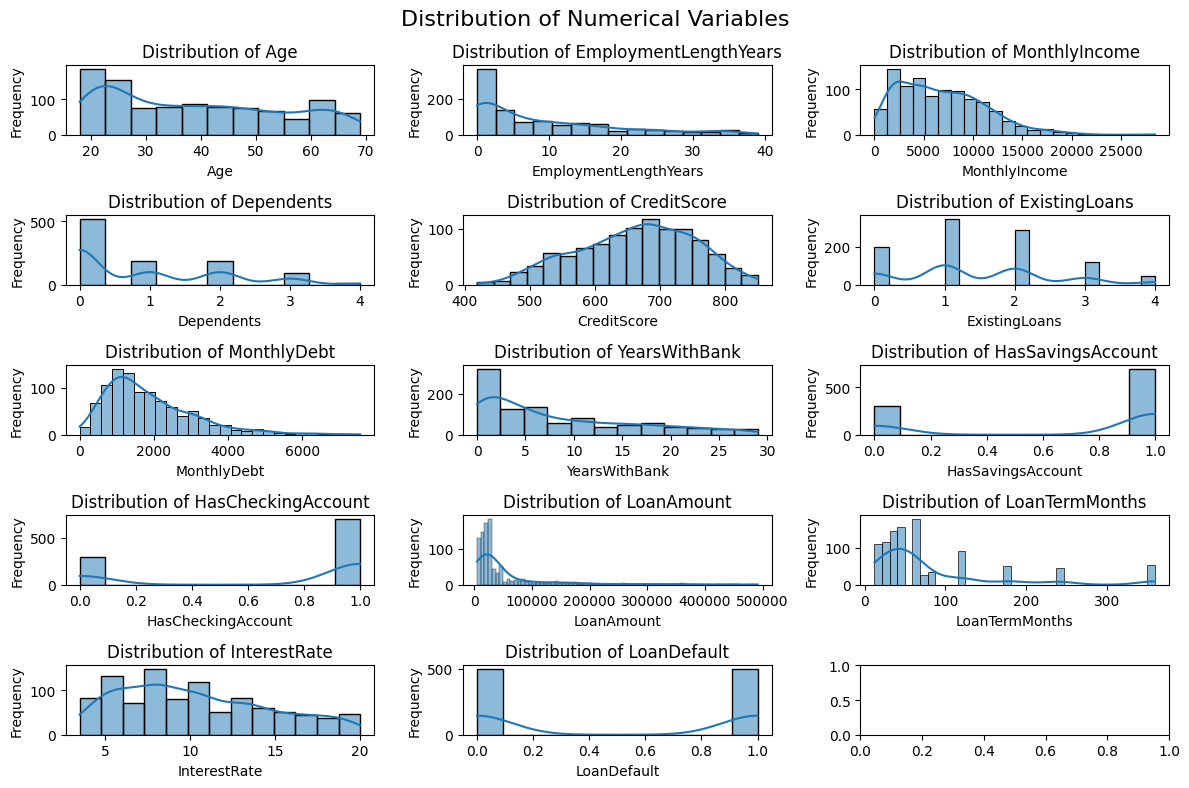

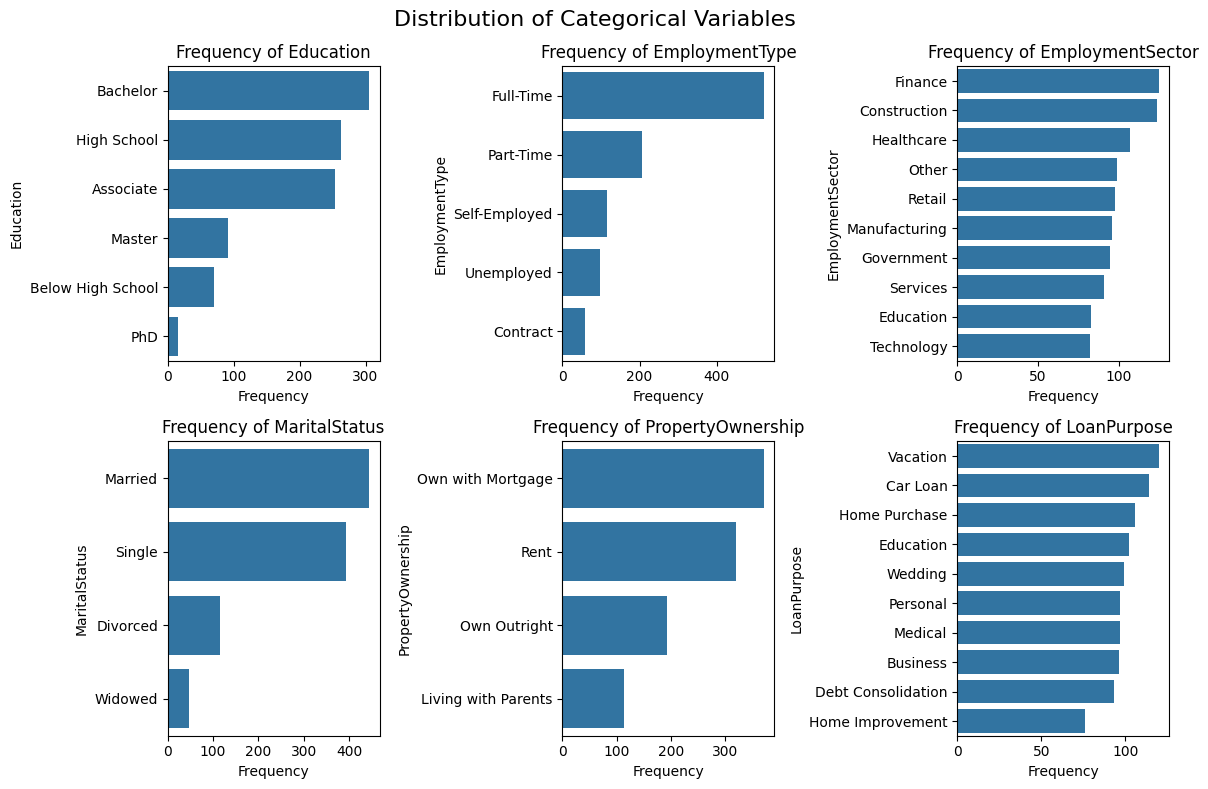

In [ ]:
# Distribution

# Numerical columns (histogram)
fig1, axes1 = plt.subplots(5, 3, figsize=(12,8))
fig1.suptitle("Distribution of Numerical Variables", fontsize=16)

for i, col in enumerate(numeric_features):
  r, c = divmod(i, 3)
  sns.histplot(clean_df[col], kde=True, ax=axes1[r, c])
  axes1[r, c].set_title(f"Distribution of {col}")
  axes1[r, c].set_xlabel(col)
  axes1[r, c].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Categorical columns (bar chart)
fig2, axes2 = plt.subplots(2, 3, figsize=(12,8))
fig2.suptitle("Distribution of Categorical Variables", fontsize=16)

for j, col in enumerate(categorical_features):
  r, c = divmod(j, 3)
  col_str = clean_df[col].astype(str).replace("nan", "NaN")
  sns.countplot(y=col_str, order=col_str.value_counts().index, ax=axes2[r, c])
  axes2[r, c].set_title(f"Frequency of {col}")
  axes2[r, c].set_xlabel("Frequency")
  axes2[r, c].set_ylabel(col)

plt.tight_layout()
plt.show()

Distribution of numerical variables: as per above descriptions

Distribution of categoricall variables:
- Education: most common education is Bachelor's degree, followed by High School and Associate. Master's degree and Below High School are moderate, and PhD are the least
- EmploymentType: most are employed full-time, some part-time, self-employed, or unemployed. Least is contract
- EmploymentSector: almost balance across all sectors
- MaritalStatus: mostly married, or single. Divorced and Windowed are of the smaller proportions
- PropertyOwnership: most own with mortgage or rent, followed by owning outright. Living with parents is the least
- LoanPurpose: relatively balance across all purposes, top purposes are for vaction, car loan, home purchase

## Correlations

In [ ]:
# Correlation

# Pairplot
print("Pairplot")
sns.pairplot(clean_df)
plt.show()

# Heatmap
print("Heatmap")
num_df = clean_df.select_dtypes(include=["number"])
plt.figure(figsize=(18,6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Correlation heatmap**

Shows how strongly two numeric variables are related to each other, using a value between:
- +1 → perfect positive relationship
- 0 → no linear relationship
- -1 → perfect negative relationship

Strong Positive Correlations
- Monthly Income ↔ Monthly Debt (~ +0.72): Higher monthly income is linked to higher monthly debt obligations.
- Loan Amount ↔ Loan Term Months (~ +0.68): Larger loan sizes tend to require longer repayment periods.
- Age ↔ Employment Length Years (~ +0.69): Older customers generally have more years in the workforce.
- Monthly Income ↔ Credit Score (~ +0.67): Higher-income customers tend to have stronger credit profiles.
- Age ↔ Years With Bank (~ +0.59): Older customers are more likely to have been with the bank longer.

Strong Negative Correlations
- Credit Score ↔ Interest Rate (~ -0.91): Higher credit scores correspond strongly with lower interest rates.
- Monthly Income ↔ Interest Rate (~ -0.64): Higher-income applicants are more likely to receive lower interest rates.
- Age ↔ Interest Rate (~ -0.52): Older borrowers typically secure lower interest rates.
- Age ↔ Loan Default (~ -0.34): Younger borrowers are slightly more likely to default than older ones.

Correlations Related to Loan Default
- Interest Rate ↔ Loan Default (~ +0.54): Higher interest rates are associated with a greater likelihood of default.
- Credit Score ↔ Loan Default (~ -0.57): Lower credit scores align with higher default risk.
- Monthly Income ↔ Loan Default (~ -0.33): Lower-income customers show a somewhat higher chance of default.
- Employment Length ↔ Loan Default (~ -0.33): Shorter work histories correlate with a slightly higher default probability.

## LLM Insights

In [ ]:
# Convert schema to prompt
schema_info = f"""
Column Data Types:
{df.dtypes}

Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns

Missing Values:
{df.isnull().sum()}

Sample Data (first 3 rows):
{df.head(3).to_string()}
"""

prompt = f"""
You are a data quality expert. Analyze the dataset information below and:

1. Identify 3 potential data quality issues.
2. Suggest data profiling steps.
3. Recommend data standardization or validation actions.

Dataset Information:
{schema_info}
"""

# Tokenize input
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [ ]:
# Generate response
outputs = model.generate(**inputs, max_new_tokens=300)
response = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Print only response (remove prompt from output)
print("\n" + "="*50)
print("AI Analysis:")
print("="*50)
print(response[len(prompt):].strip())

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



AI Analysis:
1. Potential data quality issues:

a) Missing values: The dataset has missing values in several columns, which can affect the accuracy of the analysis and modeling.

b) Data type mismatches: The dataset has mixed data types in some columns, which can lead to inconsistencies and errors in data analysis.

c) Outliers: The dataset has outliers in some columns, which can skew the results and affect the accuracy of the analysis.

2. Data profiling steps:

a) Data exploration: Explore the dataset to understand its structure, including the number of rows, columns, data types, and missing values.

b) Data cleaning: Clean the dataset by removing duplicates, filling in missing values, and correcting data type mismatches.

c) Data transformation: Transform the dataset by converting data types, normalizing data, and encoding categorical variables.

d) Data sampling: Sample the dataset to create a smaller subset for further analysis and modeling.

3. Data standardization or validation

# Feature Engineering

In [ ]:
preprocessed_df = clean_df.copy()

preprocessed_df.head()

,CustomerID,Age,Education,EmploymentType,EmploymentSector,EmploymentLengthYears,MonthlyIncome,MaritalStatus,Dependents,PropertyOwnership,...,MonthlyDebt,YearsWithBank,HasSavingsAccount,HasCheckingAccount,LoanPurpose,LoanAmount,LoanTermMonths,InterestRate,LoanDefault,LoanPurposeDescription
0,1,59,High School,Self-Employed,Technology,11,9067.159786,Single,2,Own with Mortgage,...,1583.065500,7,1,0,Personal,20789.005502,36,3.828919,0,Need funds for the next three years.
1,2,51,Below High School,Full-Time,Government,24,5068.058742,Married,1,Own with Mortgage,...,1332.052087,7,1,1,Personal,27461.583712,48,8.855769,1,I need a personal loan for this to be done.
2,3,24,Bachelor,Unemployed,Manufacturing,0,2557.541824,Single,0,Living with Parents,...,911.536097,2,1,1,Business,68862.744645,240,14.748993,1,Seeking financing to start my own company.
3,4,25,Bachelor,Full-Time,Finance,0,7535.097299,Single,0,Living with Parents,...,514.141526,6,1,0,Wedding,8841.450954,48,4.825886,0,I need a personal loan for me.
4,5,25,Master,Part-Time,Government,5,4798.465251,Married,2,Rent,...,2386.488285,3,0,1,Education,17787.927594,120,18.384157,1,"Applying for student financing for tuition, fe..."


In [ ]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   CustomerID              1000 non-null   int64   
 1   Age                     1000 non-null   int64   
 2   Education               1000 non-null   category
 3   EmploymentType          1000 non-null   category
 4   EmploymentSector        1000 non-null   category
 5   EmploymentLengthYears   1000 non-null   int64   
 6   MonthlyIncome           1000 non-null   float64 
 7   MaritalStatus           1000 non-null   category
 8   Dependents              1000 non-null   int64   
 9   PropertyOwnership       1000 non-null   category
 10  CreditScore             1000 non-null   int64   
 11  ExistingLoans           1000 non-null   int64   
 12  MonthlyDebt             1000 non-null   float64 
 13  YearsWithBank           1000 non-null   int64   
 14  HasSavingsAccount       1

## Sentiment

In [ ]:
print("Loading sentiment analysis model...")
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

print("✓ Sentiment analysis model loaded successfully!")

Loading sentiment analysis model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


✓ Sentiment analysis model loaded successfully!


--------------------------------------------------------------------------------
TASK 1: SENTIMENT CLASSIFICATION (Positive/Neutral/Negative)
--------------------------------------------------------------------------------
Classifying sentiment for customer LoanPurposeDescription...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 100/1000 LoanPurposeDescription...
  Processed 200/1000 LoanPurposeDescription...
  Processed 300/1000 LoanPurposeDescription...
  Processed 400/1000 LoanPurposeDescription...
  Processed 500/1000 LoanPurposeDescription...
  Processed 600/1000 LoanPurposeDescription...
  Processed 700/1000 LoanPurposeDescription...
  Processed 800/1000 LoanPurposeDescription...
  Processed 900/1000 LoanPurposeDescription...
  Processed 1000/1000 LoanPurposeDescription...

✓ Sentiment classification complete!

Sentiment distribution:
Sentiment
Negative    869
Unknown      66
Positive     57
Neutral       8
Name: count, dtype: int64

Percentage breakdown:
Sentiment
Negative    86.9
Unknown      6.6
Positive     5.7
Neutral      0.8
Name: proportion, dtype: float64

📝 Sample sentiment classifications:

LoanPurposeDescription: Need funds for the next three years.
Sentiment: Negative (confidence: 0.99)

LoanPurposeDescription: I need a personal loan for this to be done.
Sentiment: Negative (conf

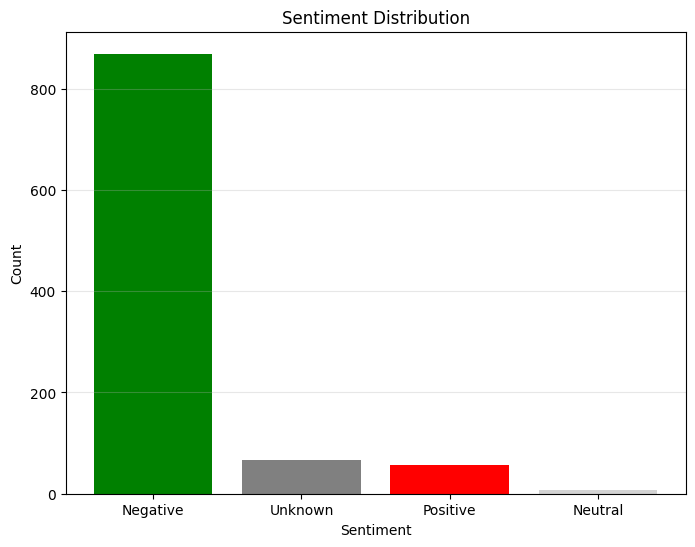

In [ ]:
# === SENTIMENT ANALYSIS ===
print("-" * 80)
print("TASK 1: SENTIMENT CLASSIFICATION (Positive/Neutral/Negative)")
print("-" * 80)

def classify_sentiment(text):
  if pd.isna(text) or text == "":
    return "Unknown", 0.0
  try:
    result = sentiment_analyzer(text[:512])[0]
    label = result["label"]
    score = result["score"]

    if label == "POSITIVE" and score > 0.6:
      return "Positive", score
    elif label == "NEGATIVE" and score > 0.6:
      return "Negative", score
    else:
      return "Neutral", score
  except Exception as e:
    return "Unknown", 0.0

print("Classifying sentiment for customer LoanPurposeDescription...")
sentiment_results = []
sentiment_scores = []

for idx, desc in enumerate(preprocessed_df["LoanPurposeDescription"]):
  sentiment, score = classify_sentiment(desc)
  sentiment_results.append(sentiment)
  sentiment_scores.append(score)

  if (idx + 1) % 100 == 0:
    print(f"  Processed {idx + 1}/{len(preprocessed_df)} LoanPurposeDescription...")

preprocessed_df["Sentiment"] = sentiment_results
preprocessed_df["Sentiment_Score"] = sentiment_scores

print("\n✓ Sentiment classification complete!")
print("\nSentiment distribution:")
print(preprocessed_df["Sentiment"].value_counts())
print(f"\nPercentage breakdown:")
print(preprocessed_df["Sentiment"].value_counts(normalize=True) * 100)

# Show examples
print("\n📝 Sample sentiment classifications:")
sample_sentiments = preprocessed_df[preprocessed_df["LoanPurposeDescription"].notna()].head(10)
for idx, row in sample_sentiments.iterrows():
    print(f"\nLoanPurposeDescription: {row['LoanPurposeDescription']}")
    print(f"Sentiment: {row['Sentiment']} (confidence: {row['Sentiment_Score']:.2f})")

# === VISUALIZE TEXT PROCESSING RESULTS ===
print("\n\nGenerating visualizations for text processing results...")

sentiment_counts = preprocessed_df["Sentiment"].value_counts()

plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'gray', 'red', 'lightgray'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
preprocessed_df.sample(10)

,CustomerID,Age,Education,EmploymentType,EmploymentSector,EmploymentLengthYears,MonthlyIncome,MaritalStatus,Dependents,PropertyOwnership,...,HasSavingsAccount,HasCheckingAccount,LoanPurpose,LoanAmount,LoanTermMonths,InterestRate,LoanDefault,LoanPurposeDescription,Sentiment,Sentiment_Score
981,982,60,Bachelor,Full-Time,Government,19,10173.968326,Married,2,Own Outright,...,1,1,Debt Consolidation,44486.152099,36,5.541237,0,I want to consolidate my debts to make sure I ...,Negative,0.987882
104,105,35,Bachelor,Full-Time,Other,10,13698.604805,Married,1,Own with Mortgage,...,0,1,Home Purchase,214856.429233,240,3.895886,1,I am applying for a home loan to purchase a ho...,Negative,0.991085
764,765,63,Bachelor,Full-Time,Finance,33,7312.289359,Married,0,Rent,...,1,1,Home Purchase,285504.418755,360,9.589835,0,Looking to buy a house for my family because I...,Negative,0.998312
95,96,27,Bachelor,Part-Time,Finance,0,7513.691738,Single,0,Rent,...,0,0,Medical,29500.814382,12,8.650631,0,Need funds for the project.,Negative,0.983306
621,622,42,Bachelor,Unemployed,Finance,0,772.820033,Single,0,Rent,...,1,1,Vacation,20872.855883,24,16.434268,1,NaN,Unknown,0.000000
221,222,28,Bachelor,Full-Time,Services,4,11706.374553,Single,0,Own with Mortgage,...,1,0,Home Purchase,312393.594358,360,5.951421,0,Looking to buy a house for my family because I...,Negative,0.993099
449,450,66,Bachelor,Self-Employed,Manufacturing,34,6792.056988,Married,3,Own with Mortgage,...,1,1,Education,87293.509405,120,10.432679,1,Need funding for my education in the U.,Negative,0.980929
205,206,50,Master,Full-Time,Healthcare,31,8852.298046,Married,1,Own Outright,...,1,1,Vacation,28403.869354,12,7.210184,0,Applying for financing to cover the costs of t...,Negative,0.928759
11,12,19,High School,Unemployed,Manufacturing,0,905.980269,Single,0,Rent,...,1,1,Home Improvement,28062.430244,36,15.704060,1,Applying for financing to cover the cost of th...,Negative,0.917295
797,798,44,High School,Full-Time,Construction,24,9630.635096,Widowed,0,Living with Parents,...,1,0,Car Loan,43209.261530,36,5.997703,0,NaN,Unknown,0.000000


In [ ]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   CustomerID              1000 non-null   int64   
 1   Age                     1000 non-null   int64   
 2   Education               1000 non-null   category
 3   EmploymentType          1000 non-null   category
 4   EmploymentSector        1000 non-null   category
 5   EmploymentLengthYears   1000 non-null   int64   
 6   MonthlyIncome           1000 non-null   float64 
 7   MaritalStatus           1000 non-null   category
 8   Dependents              1000 non-null   int64   
 9   PropertyOwnership       1000 non-null   category
 10  CreditScore             1000 non-null   int64   
 11  ExistingLoans           1000 non-null   int64   
 12  MonthlyDebt             1000 non-null   float64 
 13  YearsWithBank           1000 non-null   int64   
 14  HasSavingsAccount       1

## Perform Text Imputation for missing loan description

In [ ]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model="prajjwal1/bert-tiny"
)


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Device set to use cuda:0


📊 Missing Data Visualization

Missing LoanPurposeDescription: 66 out of 1000
Percentage: 6.60%


<Figure size 1200x400 with 0 Axes>

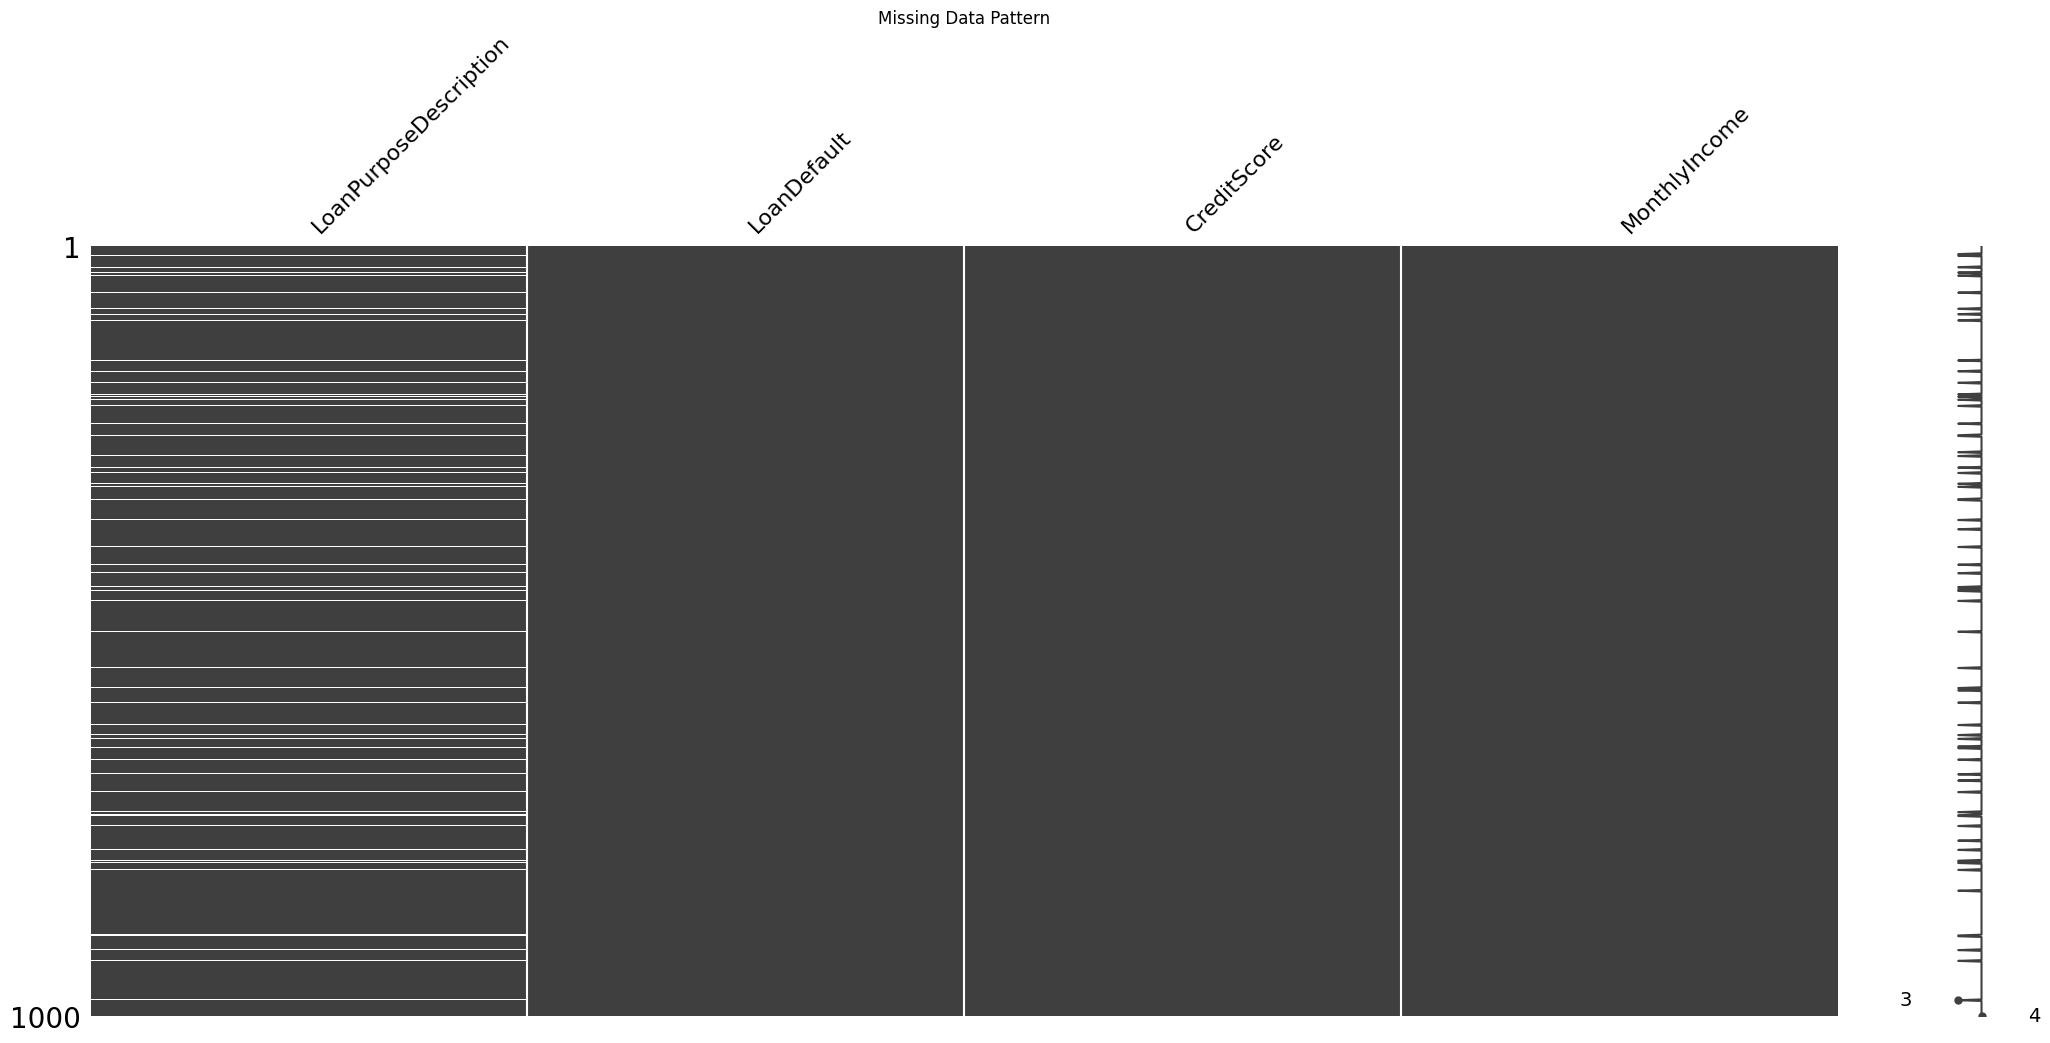

In [ ]:
# Visualize missing data
import missingno as msno
import matplotlib.pyplot as plt

print("="*60)
print("📊 Missing Data Visualization")
print("="*60)
print(f"\nMissing LoanPurposeDescription: {df['LoanPurposeDescription'].isnull().sum()} out of {len(preprocessed_df)}")
print(f"Percentage: {df['LoanPurposeDescription'].isnull().sum()/len(preprocessed_df)*100:.2f}%")

# Visualize missing data pattern
plt.figure(figsize=(12, 4))
msno.matrix(preprocessed_df[['LoanPurposeDescription', 'LoanDefault', 'CreditScore', 'MonthlyIncome']])
plt.title("Missing Data Pattern")
plt.show()

In [ ]:
# Define imputation function
def impute_loan_description(row, slm_pipeline):

    if pd.isna(row['LoanPurposeDescription']):

        purpose = row.get('LoanPurpose', None)
        sentiment = row.get('Sentiment', None)

        prompt = (
            f"The customer applied for a loan.\n"
            f"Loan purpose category: {purpose if purpose else 'Unknown'}.\n"
            f"Customer sentiment: {sentiment if sentiment else 'Unknown'}.\n"
            f"The loan purpose description is [MASK]."
        )

        try:
            prediction = slm_pipeline(prompt)[0]['token_str']
            return f"{purpose}: {prediction}" if purpose else prediction
        except:
            return "Standard loan application"

    return row['LoanPurposeDescription']


In [ ]:
# Apply imputation
print("\n⏳ Imputing missing loan descriptions...")
print("This may take a few minutes...")

preprocessed_df['LoanPurposeDescription'] = preprocessed_df.apply(
    lambda row: impute_loan_description(row, fill_mask),
    axis=1
)


print("✅ Imputation completed!")



⏳ Imputing missing loan descriptions...
This may take a few minutes...
✅ Imputation completed!


📊 Missing Data Visualization

Missing LoanPurposeDescription: 66 out of 1000
Percentage: 6.60%


<Figure size 1200x400 with 0 Axes>

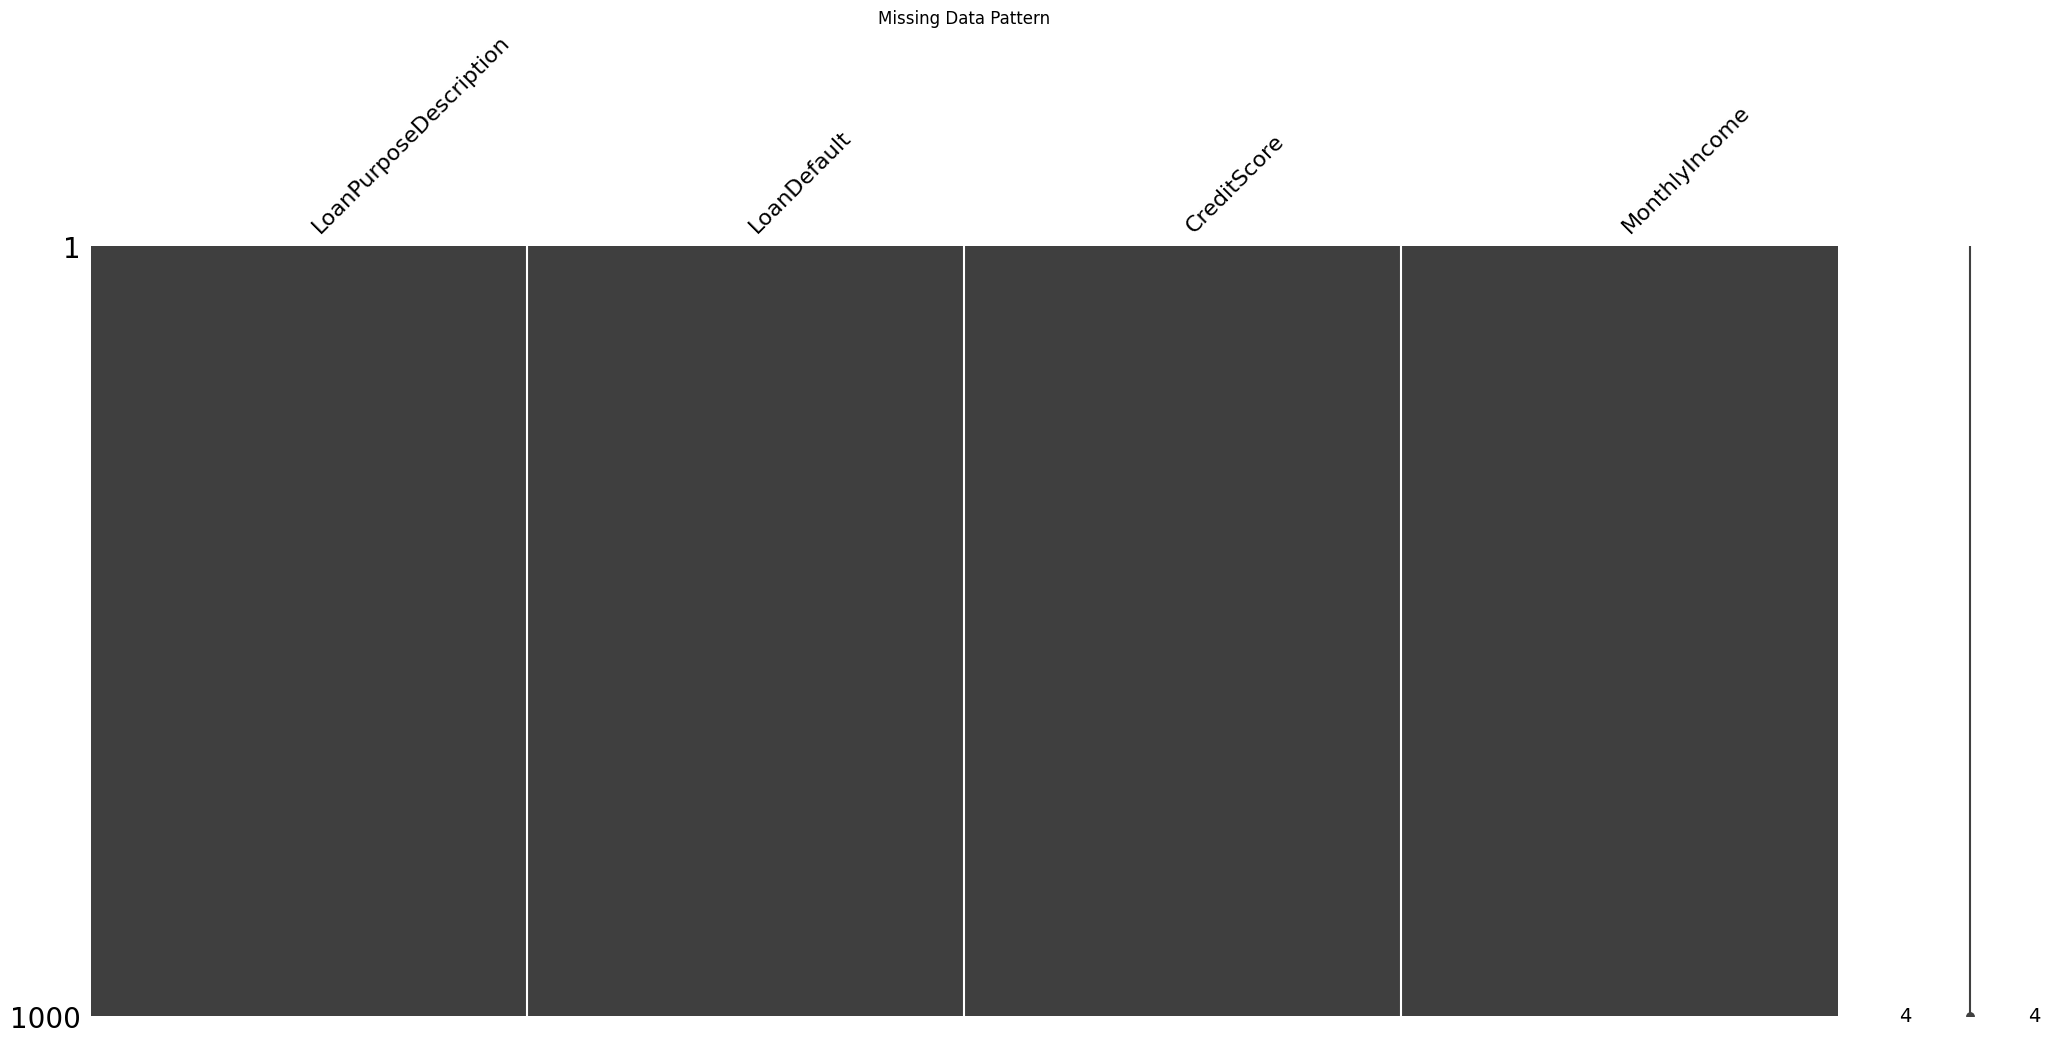

In [ ]:
# Visualize missing data
import missingno as msno
import matplotlib.pyplot as plt

print("="*60)
print("📊 Missing Data Visualization")
print("="*60)
print(f"\nMissing LoanPurposeDescription: {df['LoanPurposeDescription'].isnull().sum()} out of {len(preprocessed_df)}")
print(f"Percentage: {df['LoanPurposeDescription'].isnull().sum()/len(preprocessed_df)*100:.2f}%")

# Visualize missing data pattern
plt.figure(figsize=(12, 4))
msno.matrix(preprocessed_df[['LoanPurposeDescription', 'LoanDefault', 'CreditScore', 'MonthlyIncome']])
plt.title("Missing Data Pattern")
plt.show()

In [ ]:
preprocessed_df['LoanPurposeDescription'].value_counts(dropna=False).head(10)


,count
LoanPurposeDescription,
Applying for financing to cover the costs of the project.,60
I need a personal loan for me.,49
Need funds for the project.,44
Applying for financing to cover the cost of the project.,37
I need a business loan to expand my business.,22
I need a personal loan for my children.,12
Debt Consolidation: unknown,11
I need an education loan to pursue a career in finance.,11
Personal: unknown,9


## Encode Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Ordinal encoding (for ordinal data)
education_order = [["Below High School", "High School", "Associate", "Bachelor", "Master", "PhD"]]
ordinal_encoder = OrdinalEncoder(categories=education_order)
preprocessed_df["Education"] = ordinal_encoder.fit_transform(preprocessed_df[["Education"]])
print("✓ Encoded 'Education with ordinal order:", education_order)

# OneHot encoding (for nominal data)
nominal_cols = ["EmploymentType", "EmploymentSector", "MaritalStatus", "PropertyOwnership", "LoanPurpose", "Sentiment"]
preprocessed_df = pd.get_dummies(preprocessed_df, columns=nominal_cols, drop_first=True)
print(f"✓ One-hot encoded {len(nominal_cols)} nominal columns")

✓ Encoded 'Education with ordinal order: [['Below High School', 'High School', 'Associate', 'Bachelor', 'Master', 'PhD']]
✓ One-hot encoded 6 nominal columns


In [ ]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CustomerID                           1000 non-null   int64  
 1   Age                                  1000 non-null   int64  
 2   Education                            1000 non-null   float64
 3   EmploymentLengthYears                1000 non-null   int64  
 4   MonthlyIncome                        1000 non-null   float64
 5   Dependents                           1000 non-null   int64  
 6   CreditScore                          1000 non-null   int64  
 7   ExistingLoans                        1000 non-null   int64  
 8   MonthlyDebt                          1000 non-null   float64
 9   YearsWithBank                        1000 non-null   int64  
 10  HasSavingsAccount                    1000 non-null   int64  
 11  HasCheckingAccount             

In [ ]:
preprocessed_df.head(10)

,CustomerID,Age,Education,EmploymentLengthYears,MonthlyIncome,Dependents,CreditScore,ExistingLoans,MonthlyDebt,YearsWithBank,...,LoanPurpose_Education,LoanPurpose_Home Improvement,LoanPurpose_Home Purchase,LoanPurpose_Medical,LoanPurpose_Personal,LoanPurpose_Vacation,LoanPurpose_Wedding,Sentiment_Neutral,Sentiment_Positive,Sentiment_Unknown
0,1,59,1.0,11,9067.159786,2,770,3,1583.065500,7,...,False,False,False,False,True,False,False,False,False,False
1,2,51,0.0,24,5068.058742,1,698,3,1332.052087,7,...,False,False,False,False,True,False,False,False,False,False
2,3,24,3.0,0,2557.541824,0,480,1,911.536097,2,...,False,False,False,False,False,False,False,False,False,False
3,4,25,3.0,0,7535.097299,0,774,1,514.141526,6,...,False,False,False,False,False,False,True,False,False,False
4,5,25,4.0,5,4798.465251,2,590,4,2386.488285,3,...,True,False,False,False,False,False,False,False,False,False
5,6,18,3.0,0,2715.312586,0,576,4,982.434995,0,...,False,False,False,True,False,False,False,False,False,False
6,7,26,4.0,2,8468.695614,2,648,1,2698.065801,7,...,False,False,False,False,False,False,True,False,False,False
7,8,23,0.0,0,2079.184097,3,581,1,860.692265,1,...,False,False,False,True,False,False,False,False,False,False
8,9,46,4.0,8,9386.927084,0,688,3,3284.338250,13,...,False,False,False,True,False,False,False,False,False,False
9,10,39,3.0,13,9241.197498,2,655,1,2386.114164,11,...,False,True,False,False,False,False,False,False,False,False


## Delete customerID column and convert boolean column to integer

In [ ]:
if 'CustomerID' in preprocessed_df.columns:
    preprocessed_df = preprocessed_df.drop(columns=['CustomerID'])
    print("✓ Dropped 'CustomerID'")
else:
    print("ℹ️ 'CustomerID' not found (already removed)")


✓ Dropped 'CustomerID'


In [ ]:
bool_cols = preprocessed_df.select_dtypes(include='bool').columns

preprocessed_df[bool_cols] = preprocessed_df[bool_cols].astype(int)

print(f"✓ Converted {len(bool_cols)} boolean columns to integers")


✓ Converted 31 boolean columns to integers


In [ ]:
preprocessed_df[bool_cols].dtypes

,0
EmploymentType_Full-Time,int64
EmploymentType_Part-Time,int64
EmploymentType_Self-Employed,int64
EmploymentType_Unemployed,int64
EmploymentSector_Education,int64
EmploymentSector_Finance,int64
EmploymentSector_Government,int64
EmploymentSector_Healthcare,int64
EmploymentSector_Manufacturing,int64
EmploymentSector_Other,int64


## Upload preprocessed dataset to google drive

In [ ]:
# Make sure the folder exists
save_folder = '/content/drive/MyDrive/Group Assignment Group6'
os.makedirs(save_folder, exist_ok=True)

# Define the file name
file_name = 'final_preprocessed.csv'
file_path = os.path.join(save_folder, file_name)

# Save the DataFrame to CSV
preprocessed_df.to_csv(file_path, index=False)

print(f"✅ Preprocessed dataset saved successfully at:\n{file_path}")



✅ Preprocessed dataset saved successfully at:
/content/drive/MyDrive/Group Assignment Group6/final_preprocessed.csv
